# [Evaluations](https://wikidocs.net/259203)

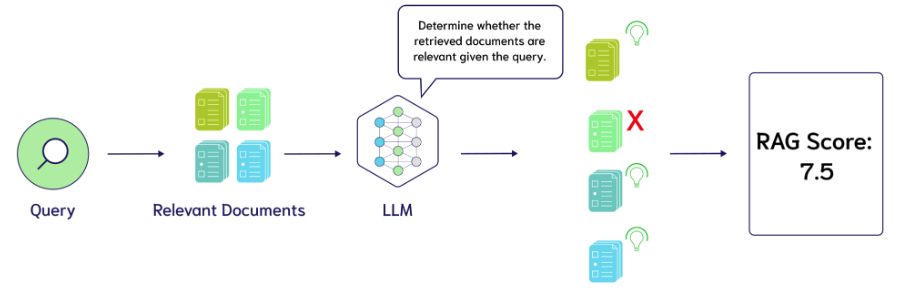

## Evaluation Score
- `Faithfulness`: 생성된 답변의 사실적 일관성을 주어진 컨텍스트와 비교하여 측정하는 지표입니다.
- `Relevancy`: 생성된 답변이 주어진 prompt에 얼마나 적절한지를 평가하는 지표입니다.
- `Context Precision`: contexts 내의 ground-truth 관련 항목들이 상위 순위에 있는지를 평가하는 지표입니다.
- `Context recall`: 검색된 context가 LLM 이 생성한 답변과 얼마나 일치하는지를 측정합니다.

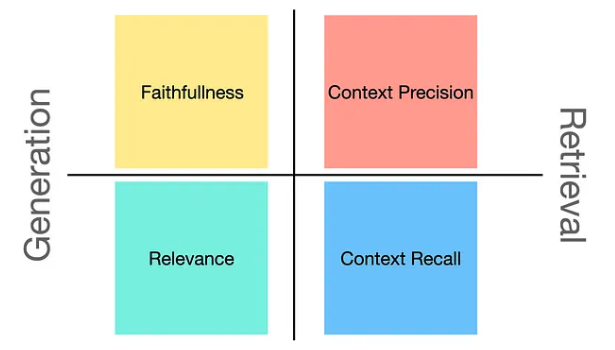

### Generation Metrics

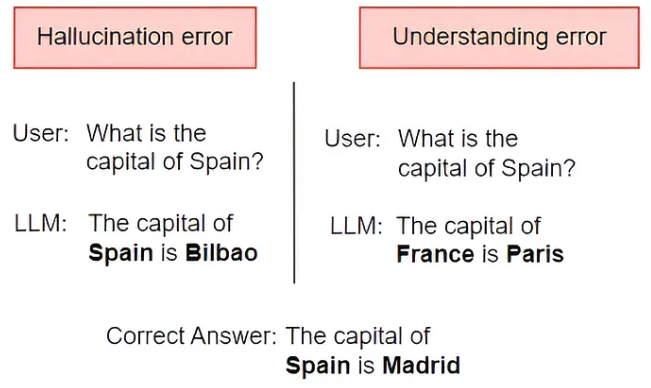

#### Answer Relevancy

- Answer Relevancy는 생성된 답변이 주어진 prompt에 얼마나 적절한지를 평가하는 지표입니다. 이 지표의 주요 특징과 계산 방법을 요약하면 다음과 같습니다:
  - `목적`: 생성된 답변의 관련성을 평가합니다.
  - `점수 해석`: 낮은 점수는 불완전하거나 중복 정보를 포함한 답변을, 높은 점수는 더 나은 관련성을 나타냅니다.
  - `계산에 사용되는 요소`: question, context, answer

- Answer Relevancy의 계산 방법: - 원래 question과 answer를 기반으로 생성된 인공적인 질문들 간의 평균 코사인 유사도로 정의됩니다.
  - $E_{g_i}$는 생성된 질문 $i$의 임베딩
  - $E_o$는 원래 질문의 임베딩
  - $N$은 생성된 질문의 수 (기본값 3)
$$
answer\; relevancy = { 1 \over N } \sum{cos(E_{g_i},\; E_{o})}
$$
또는
$$
answer\; relevancy = { 1 \over N } \sum{{ E_{g_i}E_{o} \over |E_{g_i}||E_{o}| }}
$$

- 주의사항: 실제로는 점수가 대부분 0과 1 사이에 있지만, 코사인 유사도의 특성상 수학적으로 -1에서 1 사이의 값을 가질 수 있습니다.
- 이 지표는 질문-답변 시스템의 성능을 평가하는 데 유용하며, 특히 생성된 답변이 원래 질문의 의도를 얼마나 잘 반영하는지를 측정합니다.


#### Faithfulness

- Faithfulness는 생성된 답변의 사실적 일관성을 주어진 컨텍스트와 비교하여 측정하는 지표입니다. 주요 특징은 다음과 같습니다:
  - `목적`: 답변의 사실적 일관성을 컨텍스트와 비교하여 평가합니다.
  - `계산 요소`: 답변과 검색된 컨텍스트를 사용합니다.
  - `점수 범위`: 0에서 1 사이로 조정되며, 높을수록 더 좋습니다.

- Faithfulness 점수 계산 방법:

$$
Faithfulness\; score = { |Number\; of\; claims\; in\; the\; generated\; answer\; that\; can\; be\; inferred\; from\; given\; context| \over |Total\; number\; of\; claims\; in\; the\; generated\; answer| }
$$

- 계산 과정:
  1. 생성된 답변에서 주장(claims)들을 식별합니다.
  2. 각 주장을 주어진 컨텍스트와 대조 검증하여 컨텍스트에서 추론 가능한지 확인합니다.
  3. 위 수식을 사용하여 점수를 계산합니다.

- 예시
  - `질문`: "아인슈타인은 어디서, 언제 태어났나요?"
  - `컨텍스트`: "알버트 아인슈타인(1879년 3월 14일 출생)은 독일 출신의 이론 물리학자로, 역사상 가장 위대하고 영향력 있는 과학자 중 한 명으로 여겨집니다."
  - `높은 충실도 답변`: "아인슈타인은 1879년 3월 14일 독일에서 태어났습니다."
  - `낮은 충실도 답변`: "아인슈타인은 1879년 3월 20일 독일에서 태어났습니다."

### [Retrieval Metrics](https://www.pinecone.io/learn/series/vector-databases-in-production-for-busy-engineers/rag-evaluation/)

#### Context Precision(Precision@k)
- Context Precision은 contexts 내의 ground-truth 관련 항목들이 상위 순위에 있는지를 평가하는 지표입니다.
- 이상적으로는 모든 관련 chunks가 상위 순위에 나타나야 합니다.
- 이 지표는 question, ground_truth, 그리고 contexts를 사용하여 계산되며, 0에서 1 사이의 값을 가집니다.
- 높은 점수일수록 더 나은 정밀도를 나타냅니다.

$$
Precision@k = { true\; positives@k \over (true\; positives@k) + (false\; positives@k) }
$$

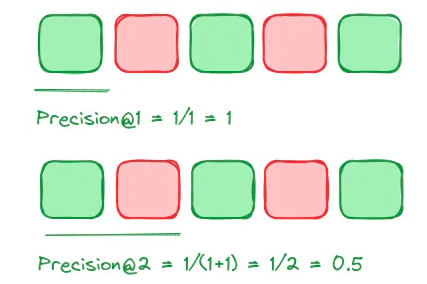

#### Context Recall(Recall@k)
- Context recall은 검색된 context가 LLM 이 생성한 답변과 얼마나 일치하는지를 측정합니다.
- 이는 question, ground truth 및 검색된 context를 사용하여 계산되며, 값은 0에서 1 사이로, 높을수록 더 나은 성능을 나타냅니다.
- Ground truth 답변에서 context recall을 추정하기 위해, ground truth 답변의 각 주장이 검색된 context에 귀속될 수 있는지 분석됩니다. 이상적인 시나리오에서는 ground truth 답변의 모든 주장이 검색된 context에 귀속될 수 있어야 합니다.

$$
Recall@k = { true\; positives@k \over (true\; positives@k) + (false\; negatives@k) }
$$

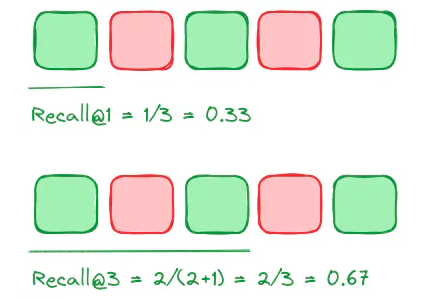

# [RAGAs - Evaluations](https://docs.ragas.io/en/stable/)

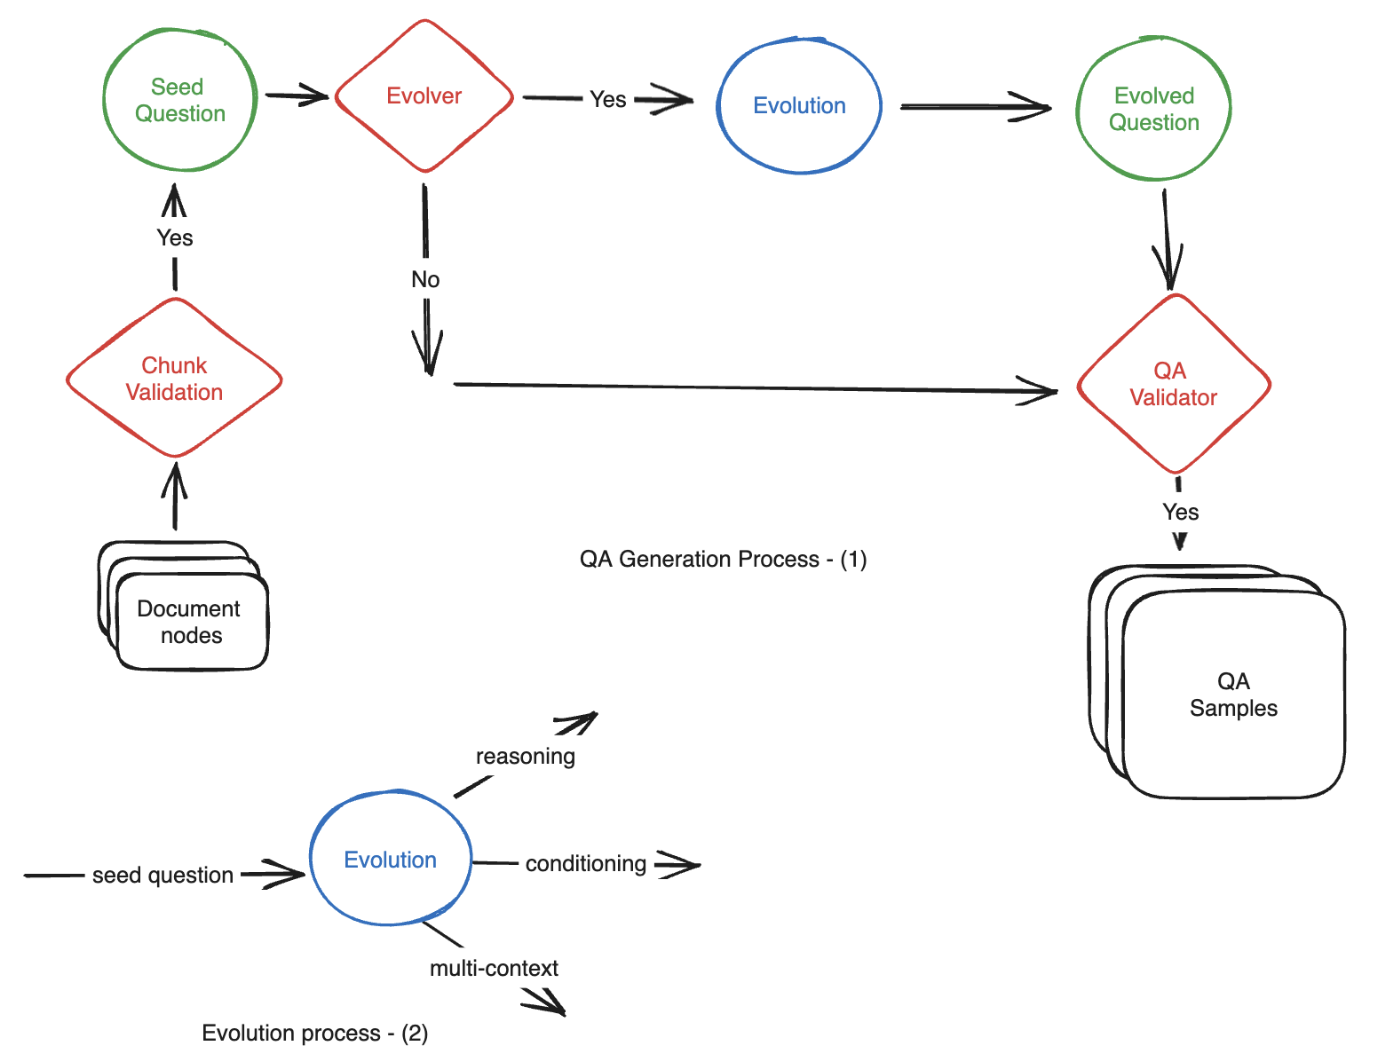

## 로드 RAG 답변 데이터셋

In [18]:
import pandas as pd 

df_test = pd.read_csv("./data/evaluation_ragas_with_answer.csv")

df_test.head(2)

,question,contexts,answer,ground_truth
0,AI의 안전하고 신뢰할 수 있는 개발과 사용에 관한 행정명령은 무엇을 포함하나요?,"[""1. \uc815\ucc45/\ubc95\uc81c 2. \uae30\uc5c5...",다음과 같이 요약됩니다.\n\n- 안전 및 보안 기준 마련: AI의 안전성과 신뢰성...,"행정명령은 AI의 안전과 보안 기준 마련, 개인정보보호, 형평성과 시민권 향상, 소..."
1,독일은 G7의 AI 국제 행동강령에 어떤 역할을 하나요?,"[""SPRi AI Brief |\n2023-12\uc6d4\ud638\nG7, \u...","독일은 G7의 구성국으로서, 2023년 히로시마 AI 프로세스를 통해 합의된 AI ...","독일은 G7의 주요 7개국 중 하나로, 2023년 10월 30일 '히로시마 AI 프..."


In [19]:
type(df_test.loc[0,["contexts"]].values[0])

str

### contexts 문자열을 list로 형변환 

In [20]:
import json

df_test["contexts"] = df_test["contexts"].apply(json.loads)

df_test.head(2)

,question,contexts,answer,ground_truth
0,AI의 안전하고 신뢰할 수 있는 개발과 사용에 관한 행정명령은 무엇을 포함하나요?,"[1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하고...",다음과 같이 요약됩니다.\n\n- 안전 및 보안 기준 마련: AI의 안전성과 신뢰성...,"행정명령은 AI의 안전과 보안 기준 마련, 개인정보보호, 형평성과 시민권 향상, 소..."
1,독일은 G7의 AI 국제 행동강령에 어떤 역할을 하나요?,"[SPRi AI Brief |\n2023-12월호\nG7, 히로시마 AI 프로세스를...","독일은 G7의 구성국으로서, 2023년 히로시마 AI 프로세스를 통해 합의된 AI ...","독일은 G7의 주요 7개국 중 하나로, 2023년 10월 30일 '히로시마 AI 프..."


In [21]:
type(df_test.loc[0,["contexts"]].values[0])

list

### 특수 문자 등이 많이 있어서, 클린징 작업 진행 

In [22]:
df_test.loc[0,["contexts"]].values[0]

['1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 발표\nKEY Contents\nn 미국 바이든 대통령이 ‘안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령’에 서명하고\n광범위한 행정 조치를 명시\nn 행정명령은 △AI의 안전과 보안 기준 마련 △개인정보보호 △형평성과 시민권 향상 △소비자\n보호 △노동자 지원 △혁신과 경쟁 촉진 △국제협력을 골자로 함\n£바이든 대통령, AI 행정명령 통해 안전하고 신뢰할 수 있는 AI 개발과 활용 추진\nn 미국 바이든 대통령이 2023년 10월 30일 연방정부 차원에서 안전하고 신뢰할 수 있는 AI 개발과\n사용을 보장하기 위한 행정명령을 발표\n∙ 행정명령은 △AI의 안전과 보안 기준 마련 △개인정보보호 △형평성과 시민권 향상 △소비자 보호\n△노동자 지원 △혁신과 경쟁 촉진 △국제협력에 관한 내용을 포괄',
 '∙ AI 시스템의 효과적 거버넌스를 위한 도구 개발* 및 안전한 AI 시스템 개발을 위한 새로운 접근 방식 연구를 수행\n* 편향된 훈련 데이터에 대한 분석기술, 민감한 정보를 포함하는 AI 시스템에 대한 미세 조정 방법\nn (정보 교류 활성화) 현행 개인정보보호와 데이터 규제 하에서 연구소와 정책입안자, 국제 파트너,\n학계, 시민사회 및 일반 대중과 정보 공유 채널을 구축\n∙ AI 안전성 정상회의(AI Safety Summit)에서 합의된 대로 첨단 AI 모델의 평가 후 해당 모델이 배포된\n타국의 정부 및 연구소와 평가 결과를 공유하고, 학계와 대중이 AI 시스템의 피해와 취약점을 보고할 수\n있는 명확한 절차를 수립\n☞ 출처 : Gov.uk, Introducing the AI Safety Institute, 2023.11.02.',
 '△노동자 지원 △혁신과 경쟁 촉진 △국제협력에 관한 내용을 포괄\nn (AI 안전과 보안 기준) 강력한 AI 시스템을 개발하는 기업에게 안전 테스트 결과와 시스템에 관한

In [23]:
import re

# 텍스트 정제 함수
def clean_text(text):
    text = text.replace("\n", " ")  # 개행 제거
    text = re.sub(r"[∙△£☞*·■◆▶◇▪•]", " ", text)  # 특정 특수문자 제거
    text = re.sub(r"[^가-힣a-zA-Z0-9.,()\s]", " ", text)  # 한글, 영문, 숫자, ., , , () 제외하고 제거
    text = re.sub(r"\s+", " ", text)  # 여러 공백 → 하나로
    return text.strip()

In [24]:
df_test["contexts"] = df_test["contexts"].map(lambda lst: [ clean_text(text) for text in lst])

In [25]:
df_test.loc[0,["contexts"]].values[0]

['1. 정책 법제 2. 기업 산업 3. 기술 연구 4. 인력 교육 미국, 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 발표 KEY Contents n 미국 바이든 대통령이 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 에 서명하고 광범위한 행정 조치를 명시 n 행정명령은 AI의 안전과 보안 기준 마련 개인정보보호 형평성과 시민권 향상 소비자 보호 노동자 지원 혁신과 경쟁 촉진 국제협력을 골자로 함 바이든 대통령, AI 행정명령 통해 안전하고 신뢰할 수 있는 AI 개발과 활용 추진 n 미국 바이든 대통령이 2023년 10월 30일 연방정부 차원에서 안전하고 신뢰할 수 있는 AI 개발과 사용을 보장하기 위한 행정명령을 발표 행정명령은 AI의 안전과 보안 기준 마련 개인정보보호 형평성과 시민권 향상 소비자 보호 노동자 지원 혁신과 경쟁 촉진 국제협력에 관한 내용을 포괄',
 'AI 시스템의 효과적 거버넌스를 위한 도구 개발 및 안전한 AI 시스템 개발을 위한 새로운 접근 방식 연구를 수행 편향된 훈련 데이터에 대한 분석기술, 민감한 정보를 포함하는 AI 시스템에 대한 미세 조정 방법 n (정보 교류 활성화) 현행 개인정보보호와 데이터 규제 하에서 연구소와 정책입안자, 국제 파트너, 학계, 시민사회 및 일반 대중과 정보 공유 채널을 구축 AI 안전성 정상회의(AI Safety Summit)에서 합의된 대로 첨단 AI 모델의 평가 후 해당 모델이 배포된 타국의 정부 및 연구소와 평가 결과를 공유하고, 학계와 대중이 AI 시스템의 피해와 취약점을 보고할 수 있는 명확한 절차를 수립 출처 Gov.uk, Introducing the AI Safety Institute, 2023.11.02.',
 '노동자 지원 혁신과 경쟁 촉진 국제협력에 관한 내용을 포괄 n (AI 안전과 보안 기준) 강력한 AI 시스템을 개발하는 기업에게 안전 테스트 결과와 시스템에 관한 주요 정보를 미국 정부와 공유할 것을 요구하고, AI 시스템의 안전성과 신뢰성 확인을 위한

| Key              | 타입                   | 필수 여부        | 설명                                     |
| ---------------- | -------------------- | ------------ | -------------------------------------- |
| **question**     | `str`                | ✅ 필수         | 사용자가 입력한 질문 (prompt)                   |
| **contexts**     | `List[str]`          | ✅ 필수         | RAG 시스템이 검색(retrieve)한 문맥(Context) 리스트 |
| **answers**      | `str`                | ✅ 필수         | LLM이 생성한 답변 (RAG 응답 결과)                |
| **ground_truth** | `str` 또는 `List[str]` | ⚙️ 평가에 따라 필요 | 실제 정답 (정답 문장 혹은 요약된 기준 텍스트)            |


### pandas를 dataset으로 변환 

In [26]:
from datasets import Dataset

dataset_test = Dataset.from_pandas(df_test)
dataset_test

Dataset({
    features: ['question', 'contexts', 'answer', 'ground_truth'],
    num_rows: 10
})

## answer 평가 by RAGAS

In [27]:
from ragas import evaluate
from ragas.metrics import (
    answer_relevancy,
    faithfulness,
    context_recall,
    context_precision,
)

### Relevancy
> 생성된 답변이 주어진 prompt에 얼마나 적절한지를 평가하는 지표입니다.

In [39]:
from langchain_openai import ChatOpenAI

result_answer_relevancy = evaluate(
    dataset=dataset_test,
    metrics=[answer_relevancy],
    llm=ChatOpenAI(model="gpt-4o-mini")
)

Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

In [40]:
print(f"RAGAs의 평가결과: {result_answer_relevancy}")

RAGAs의 평가결과: {'answer_relevancy': 0.8436}


In [43]:
df_answer_relevancy = result_answer_relevancy.to_pandas()
df_answer_relevancy.head()

,user_input,retrieved_contexts,response,reference,answer_relevancy
0,AI의 안전하고 신뢰할 수 있는 개발과 사용에 관한 행정명령은 무엇을 포함하나요?,"[1. 정책 법제 2. 기업 산업 3. 기술 연구 4. 인력 교육 미국, 안전하고 ...",다음과 같이 요약됩니다.\n\n- 안전 및 보안 기준 마련: AI의 안전성과 신뢰성...,"행정명령은 AI의 안전과 보안 기준 마련, 개인정보보호, 형평성과 시민권 향상, 소...",0.833159
1,독일은 G7의 AI 국제 행동강령에 어떤 역할을 하나요?,"[SPRi AI Brief 2023 12월호 G7, 히로시마 AI 프로세스를 통해 ...","독일은 G7의 구성국으로서, 2023년 히로시마 AI 프로세스를 통해 합의된 AI ...","독일은 G7의 주요 7개국 중 하나로, 2023년 10월 30일 '히로시마 AI 프...",0.838836
2,"프랑스는 AI 안전성 정상회의에서 어떤 역할을 하였고, 그 결과로 무엇을 계획하고 ...","[관련된 경우 해당 국가와 결과를 공유하며, 적절한 시기에 공동 표준 개발을 위해 ...",- 역할: 프랑스는 AI 안전성 정상회의에 참가한 28개국 중 하나로 참여했습니다....,프랑스 정부는 AI 안전성 정상회의에서 1년 후 대면 정상회의를 개최할 예정입니다....,0.890203
3,캘리 맥커넌이 제기한 저작권 소송의 결과는 무엇인가요?,"[SPRi AI Brief 2023 12월호 미국 법원, 예술가들이 생성 AI 기업...",결과는 기각되었습니다. 미국 캘리포니아 북부지방법원은 캘리 맥커넌이 제기한 저작권 ...,"캘리 맥커넌은 미드저니, 스태빌리티AI, 디비언트아트를 상대로 제기한 저작권 침해 ...",0.801792
4,프랑스가 EU AI 법 최종협상에서 기반모델 규제에 반대하는 이유는 무엇인가요?,"[SPRi AI Brief 2023 12월호 EU AI 법 3자 협상, 기반모델 규...",- 프랑스는 기반모델 전반에 대한 일괄적인 규제가 기술 중립성과 위험 기반의 AI ...,"프랑스는 EU AI 법 최종협상에서 기반모델 규제에 반대하며, 자율적 행동강령을 도...",0.860572


### Faithfulness
> 생성된 답변의 사실적 일관성을 주어진 컨텍스트와 비교하여 측정하는 지표입니다.

In [44]:
from langchain_openai import ChatOpenAI

result_faithfulness = evaluate(
    dataset=dataset_test,
    metrics=[faithfulness],
    llm=ChatOpenAI(model="gpt-4o-mini")
)

Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

In [45]:
print(f"RAGAs의 평가결과: {result_faithfulness}")

RAGAs의 평가결과: {'faithfulness': 0.8750}


In [46]:
df_faithfulness = result_faithfulness.to_pandas()
df_faithfulness.head()

,user_input,retrieved_contexts,response,reference,faithfulness
0,AI의 안전하고 신뢰할 수 있는 개발과 사용에 관한 행정명령은 무엇을 포함하나요?,"[1. 정책 법제 2. 기업 산업 3. 기술 연구 4. 인력 교육 미국, 안전하고 ...",다음과 같이 요약됩니다.\n\n- 안전 및 보안 기준 마련: AI의 안전성과 신뢰성...,"행정명령은 AI의 안전과 보안 기준 마련, 개인정보보호, 형평성과 시민권 향상, 소...",1.0
1,독일은 G7의 AI 국제 행동강령에 어떤 역할을 하나요?,"[SPRi AI Brief 2023 12월호 G7, 히로시마 AI 프로세스를 통해 ...","독일은 G7의 구성국으로서, 2023년 히로시마 AI 프로세스를 통해 합의된 AI ...","독일은 G7의 주요 7개국 중 하나로, 2023년 10월 30일 '히로시마 AI 프...",1.0
2,"프랑스는 AI 안전성 정상회의에서 어떤 역할을 하였고, 그 결과로 무엇을 계획하고 ...","[관련된 경우 해당 국가와 결과를 공유하며, 적절한 시기에 공동 표준 개발을 위해 ...",- 역할: 프랑스는 AI 안전성 정상회의에 참가한 28개국 중 하나로 참여했습니다....,프랑스 정부는 AI 안전성 정상회의에서 1년 후 대면 정상회의를 개최할 예정입니다....,0.0
3,캘리 맥커넌이 제기한 저작권 소송의 결과는 무엇인가요?,"[SPRi AI Brief 2023 12월호 미국 법원, 예술가들이 생성 AI 기업...",결과는 기각되었습니다. 미국 캘리포니아 북부지방법원은 캘리 맥커넌이 제기한 저작권 ...,"캘리 맥커넌은 미드저니, 스태빌리티AI, 디비언트아트를 상대로 제기한 저작권 침해 ...",1.0
4,프랑스가 EU AI 법 최종협상에서 기반모델 규제에 반대하는 이유는 무엇인가요?,"[SPRi AI Brief 2023 12월호 EU AI 법 3자 협상, 기반모델 규...",- 프랑스는 기반모델 전반에 대한 일괄적인 규제가 기술 중립성과 위험 기반의 AI ...,"프랑스는 EU AI 법 최종협상에서 기반모델 규제에 반대하며, 자율적 행동강령을 도...",1.0


### Context recall
> 검색된 context가 LLM 이 생성한 답변과 얼마나 일치하는지를 측정합니다.

In [47]:
from langchain_openai import ChatOpenAI

result_context_recall = evaluate(
    dataset=dataset_test,
    metrics=[context_recall],
    llm=ChatOpenAI(model="gpt-4o-mini")
)

Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

In [48]:
print(f"RAGAs의 평가결과: {result_context_recall}")

RAGAs의 평가결과: {'context_recall': 0.9500}


In [49]:
df_context_recall = result_context_recall.to_pandas()
df_context_recall.head()

,user_input,retrieved_contexts,response,reference,context_recall
0,AI의 안전하고 신뢰할 수 있는 개발과 사용에 관한 행정명령은 무엇을 포함하나요?,"[1. 정책 법제 2. 기업 산업 3. 기술 연구 4. 인력 교육 미국, 안전하고 ...",다음과 같이 요약됩니다.\n\n- 안전 및 보안 기준 마련: AI의 안전성과 신뢰성...,"행정명령은 AI의 안전과 보안 기준 마련, 개인정보보호, 형평성과 시민권 향상, 소...",1.0
1,독일은 G7의 AI 국제 행동강령에 어떤 역할을 하나요?,"[SPRi AI Brief 2023 12월호 G7, 히로시마 AI 프로세스를 통해 ...","독일은 G7의 구성국으로서, 2023년 히로시마 AI 프로세스를 통해 합의된 AI ...","독일은 G7의 주요 7개국 중 하나로, 2023년 10월 30일 '히로시마 AI 프...",1.0
2,"프랑스는 AI 안전성 정상회의에서 어떤 역할을 하였고, 그 결과로 무엇을 계획하고 ...","[관련된 경우 해당 국가와 결과를 공유하며, 적절한 시기에 공동 표준 개발을 위해 ...",- 역할: 프랑스는 AI 안전성 정상회의에 참가한 28개국 중 하나로 참여했습니다....,프랑스 정부는 AI 안전성 정상회의에서 1년 후 대면 정상회의를 개최할 예정입니다....,0.5
3,캘리 맥커넌이 제기한 저작권 소송의 결과는 무엇인가요?,"[SPRi AI Brief 2023 12월호 미국 법원, 예술가들이 생성 AI 기업...",결과는 기각되었습니다. 미국 캘리포니아 북부지방법원은 캘리 맥커넌이 제기한 저작권 ...,"캘리 맥커넌은 미드저니, 스태빌리티AI, 디비언트아트를 상대로 제기한 저작권 침해 ...",1.0
4,프랑스가 EU AI 법 최종협상에서 기반모델 규제에 반대하는 이유는 무엇인가요?,"[SPRi AI Brief 2023 12월호 EU AI 법 3자 협상, 기반모델 규...",- 프랑스는 기반모델 전반에 대한 일괄적인 규제가 기술 중립성과 위험 기반의 AI ...,"프랑스는 EU AI 법 최종협상에서 기반모델 규제에 반대하며, 자율적 행동강령을 도...",1.0


### Context Precision
> contexts 내의 ground-truth 관련 항목들이 상위 순위에 있는지를 평가하는 지표입니다.

In [50]:
from langchain_openai import ChatOpenAI

result_context_precision = evaluate(
    dataset=dataset_test,
    metrics=[context_precision],
    llm=ChatOpenAI(model="gpt-4o-mini")
)

Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

In [51]:
print(f"RAGAs의 평가결과: {result_context_precision}")

RAGAs의 평가결과: {'context_precision': 0.9750}


In [52]:
df_result_context_precision = result_context_precision.to_pandas()
df_result_context_precision.head()

,user_input,retrieved_contexts,response,reference,context_precision
0,AI의 안전하고 신뢰할 수 있는 개발과 사용에 관한 행정명령은 무엇을 포함하나요?,"[1. 정책 법제 2. 기업 산업 3. 기술 연구 4. 인력 교육 미국, 안전하고 ...",다음과 같이 요약됩니다.\n\n- 안전 및 보안 기준 마련: AI의 안전성과 신뢰성...,"행정명령은 AI의 안전과 보안 기준 마련, 개인정보보호, 형평성과 시민권 향상, 소...",1.000000
1,독일은 G7의 AI 국제 행동강령에 어떤 역할을 하나요?,"[SPRi AI Brief 2023 12월호 G7, 히로시마 AI 프로세스를 통해 ...","독일은 G7의 구성국으로서, 2023년 히로시마 AI 프로세스를 통해 합의된 AI ...","독일은 G7의 주요 7개국 중 하나로, 2023년 10월 30일 '히로시마 AI 프...",1.000000
2,"프랑스는 AI 안전성 정상회의에서 어떤 역할을 하였고, 그 결과로 무엇을 계획하고 ...","[관련된 경우 해당 국가와 결과를 공유하며, 적절한 시기에 공동 표준 개발을 위해 ...",- 역할: 프랑스는 AI 안전성 정상회의에 참가한 28개국 중 하나로 참여했습니다....,프랑스 정부는 AI 안전성 정상회의에서 1년 후 대면 정상회의를 개최할 예정입니다....,0.916667
3,캘리 맥커넌이 제기한 저작권 소송의 결과는 무엇인가요?,"[SPRi AI Brief 2023 12월호 미국 법원, 예술가들이 생성 AI 기업...",결과는 기각되었습니다. 미국 캘리포니아 북부지방법원은 캘리 맥커넌이 제기한 저작권 ...,"캘리 맥커넌은 미드저니, 스태빌리티AI, 디비언트아트를 상대로 제기한 저작권 침해 ...",1.000000
4,프랑스가 EU AI 법 최종협상에서 기반모델 규제에 반대하는 이유는 무엇인가요?,"[SPRi AI Brief 2023 12월호 EU AI 법 3자 협상, 기반모델 규...",- 프랑스는 기반모델 전반에 대한 일괄적인 규제가 기술 중립성과 위험 기반의 AI ...,"프랑스는 EU AI 법 최종협상에서 기반모델 규제에 반대하며, 자율적 행동강령을 도...",1.000000
